# Prelab 06

After having read the Introduction of the Lab manual we will investigate the performance of a PID controller on the given system. For that, we use frequency domain methods to easily simulate the closed-loop control. For the purposes of simplifying the modeling we discard the relationship between motor angles and plate pose - we skip the motors and links and assume that the output of the controller is directly the plate angle. </br>

This Jupyter notebook contains the skeleton of the code.  </br>
Put your code as well as the answers in the respective sections and hand in a single Jupyter notebook (.ipynb) file.

In [58]:
import numpy as np
from control import (
    TransferFunction,
    step_response,
    impulse_response,
    tf,
    pade,
    forced_response,
    series,
    feedback,
    poles
)
from matplotlib import pyplot as plt

###  Prelab Q1
To analyze the system, it is sufficient to only consider one of the two directions of movement. We will look at the behaviour of the PID controller with movement in x-direction. 
Calculate the open loop transfer function of this plant. You can use the linearized differential equation to calculate the transfer function.
The transfer function is given by the Laplace transform of small changes in output over small changes in the input. The constant $g$ is approximated by $10m/s^2$ (for the formula 6.6 in the lab manual). Plot the impulse and the step response of the open loop transfer function using the functions `impulse_response()` and `step_response()` from the `python-control` package. </br>

**Use a step of 0.1 magnitude**, this means your input signal wants to control the ball 10 cm off-center. </br>

On your report, show the plots as subplots next to each other and comment and explain the difference between step and impulse response and what they mean for the open-loop system. </br>

**Don't forget to add axis labels to your plots to make them readable and get full marks.**

When defining transfer functions using the `python-control` package, you can define them by specifying the polynomial coefficients of the numerator and denominator or using algebraic expressions after initializing `s=TransferFunction.s`

When manipulating transfer functions (in series, in parallel, or in feedback), there exist different ways to express the resulting transfer function of such interconnections. </br>
Look at functions that are already imported for you and their documentation to understand how they work.


Documentation: <href/> https://python-control.readthedocs.io/en/0.10.1/<href>

In [59]:
T = np.linspace(0, 5, 50001)

# linearized ODE:
# x_dot_dot = (3/5) * g * sin(theta_y) ≈ (3/5) * g * theta_y

# TF = X(s) / U(s) = (3g) / (5s^2) whereas g = 10
# Therefore TF = 6 / (s^2)

# Define transfer function of plant
s = TransferFunction.s
P = 6 / (s**2)


Impulse Response at x(t=1) =  5.999999999999437
Step Response at x(t=1) =  0.30000000000000937
Step Response at x(t=2) =  1.2000000000006752


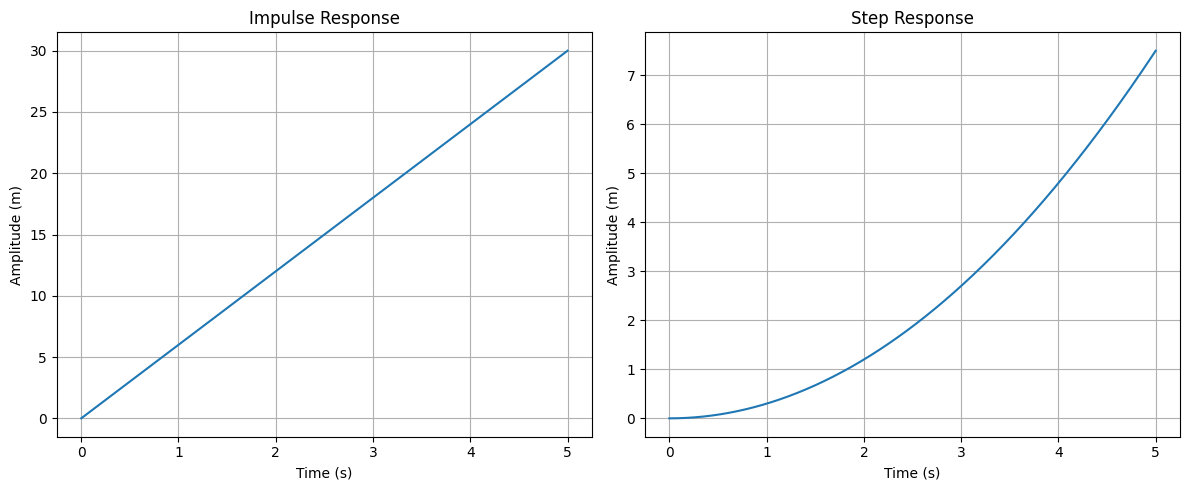

In [148]:
# Compute and plot the Impulse and step response of the uncontrolled system
imp = impulse_response(P, T)
step = step_response(P, T)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(imp.time, imp.outputs)
axs[0].set_title("Impulse Response")
axs[0].set_xlabel("Time (s)")
axs[0].set_ylabel("Amplitude (m)")
axs[0].grid()

print("Impulse Response at x(t=1) = ", imp.outputs[10000])


axs[1].plot(step.time, 0.1*step.outputs)
axs[1].set_title("Step Response")
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Amplitude (m)")
axs[1].grid()

print("Step Response at x(t=1) = ", 0.1*step.outputs[10000])
print("Step Response at x(t=2) = ", 0.1*step.outputs[20000])

plt.tight_layout()
plt.show()

Comment and explain the difference between step and impulse response and what they mean for the open-loop system </br>


<font color=orange> our transfer function is a pure double integrator, meaning there's no damping or spring. X(s) = P(s) * U(s) = 6/s^2 * 1/s for the linearized system.

For the impulse response, U(s) = 1 and therefore X(s) being a double integrator. It converts to x(t) = 6*t. This can be seen clearly with the linear behaviour of the x(t) in the plot, with x(t=1)=6. This makes conceptually sense as well since for an impulse applied for once should roll the ball indefinitely on the plate in a constant manner as we're negleting friction, air resistance etc.

For the step response, U(s) = 0.1/s and therefore X(s) being a triple integrator. It converts to x(t) = 0.3*t^2. This can be seen clearly with the quadratic behaviour of the x(t) int the plot, with x(t=1) = 0.3 and x(t=2) = 1.2. This makes conceptually sense as well since a constant input in form of an acceleration results in an increasing velocity. 

These two plots show that the system is physically unstable in the open loop, as it will deviate either with constant or quadratically increasing velocity away from the origin when being excited with an impulse or step. Meaning it requires feedback control to stabilize.
 </font>



### Prelab Q2

Create the transfer function of the controller and close the feedback loop according to Fig. 6.2. in the lab manual. Note that the inverse kinematics and servos are now skipped. You can further assume that the camera feedback has a transfer function of 1. For control in x-direction, this results in the simplified system depicted in the figure below. Plot the Step (0.1 magnitude) response for $K_p=20, K_i=1, K_d=2$. 

Is this response under-damped, critically damped or over-damped? 

<font color=orange>
To determine if a response is underdamped, critically damped or overdamped, we need to assess the CL system poles. When the poles include a complex conjugate pair, the system is underdamped as it oscillates. When all poles are real and unique, the system is overdamped. If two real roots are the same and no conjugate pari exists, the system is critically damped.

The Kd=2 system has a complex conjugate pair and is therefore underdamped.
The Kd=20 system has all real and unique poles, and is therefore overdamped
</font>

What happens to your response if you increase $K_d$ to 20? 

<font color=orange> As already stated in the previous question, the poled of the CL system change. In the Kd=20 system we have only real poles, meaning there is no oscillation in the system. This also leads to the system being now overdamped, resulting in almost no overshoot in the step response </font>

If you consider our real system with visual feedback, what could be the risk of increasing $K_d$ too high? </br>
<font color=orange> A higher Kd value increases the importance of the derivative in the controller, which reacts to very fast changes. If we increase Kd therefore too much in our system we could suddenly amplify measurement noise. This is because we will always have some noise in a visual system as the camera samples with 60 Hz, we have motion blur etc so the tracking is inherently a bit jittery.
Therefore there's a tradeoff between reducing overshoot and keep reaction of the controller to noise small with Kd. </font>

The script that you hand in should show the plot for the two $K_d$ values and the answers to the questions above. For this Prelab, write all your answers in Markdown cells within this file.

In [63]:
# Create the transfer function of the controller with closed feedback loop and the given parameters
Kp = 20
Ki = 1
Kd = 2
Kd_ = 20

controller = Kp + (1/s) * Ki + s * Kd
controller_ = Kp + (1/s) * Ki + s * Kd_

# TF of open loop system from error to output
forward = controller * P
forward_ = controller_ * P

# TF of closed loop system
T1 = feedback(forward) # forward / (1 + forward)
T1_ = feedback(forward_)

# following the characteristic polynomial (denominator of CL system)
# s**3 + 6Kds**2 + 6Kps + 6Ki

# its roots (CL poles) are:
poles_T1 = poles(T1)
poles_T1_ = poles(T1_)

print("Poles with Kd=2: ", poles_T1)
print("Poles with Kd=20: ", poles_T1_)


Poles with Kd=2:  [-5.97487427+9.14879146j -5.97487427-9.14879146j -0.05025146+0.j        ]
Poles with Kd=20:  [-1.18991952e+02+0.j -9.55262772e-01+0.j -5.27850342e-02+0.j]


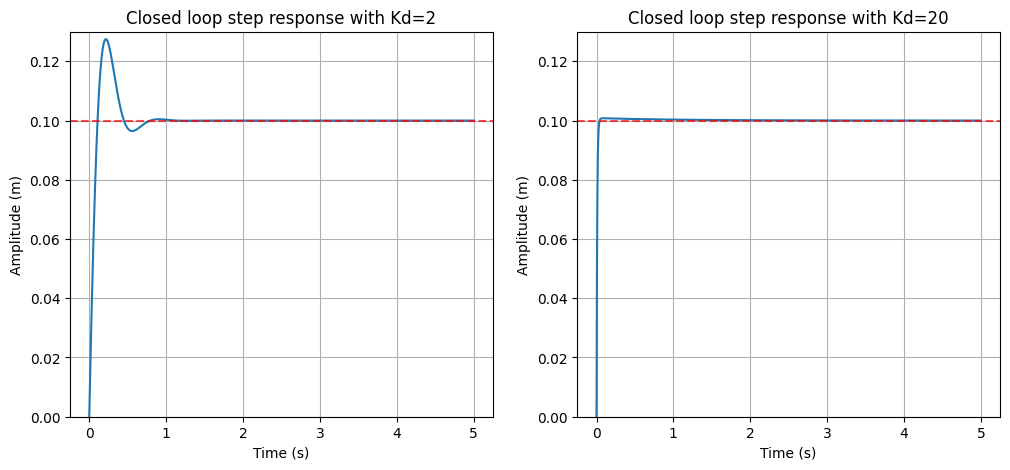

In [147]:
step_T1 = step_response(T1, T)
step_T1_ = step_response(T1_, T)


fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(step_T1.time, 0.1*step_T1.outputs)
ax[0].set_title("Closed loop step response with Kd=2")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude (m)")
ax[0].set_ylim(0, 0.13)
ax[0].axhline(y=0.1, color='r', linestyle='--', alpha=0.7)
ax[0].grid()

ax[1].plot(step_T1_.time, 0.1*step_T1_.outputs) 
ax[1].set_title("Closed loop step response with Kd=20")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Amplitude (m)")
ax[1].set_ylim(0, 0.13)
ax[1].axhline(y=0.1, color='r', linestyle='--', alpha=0.7)
ax[1].grid()


### Prelab Q3

The real system has a small latency due to the image-processing part happening on the Pixy cam. Although the setup with the Pixy cam minimizes this delay, it could still be big enough to impact our controller design.

Simulate this time-delay by adding it to our control loop. A time delay in the frequency domain is given by the exponential function $e^{−sT}$, where $s$ is the Laplace variable and $T$ is the delay. 

If we assume that the pixycam introduces a delay of 80ms, you will see that the system is no longer stable.

Find parameters that stabilize the system with a steady state error at 5 seconds that is smaller than 0.001 (=1mm) for a step input of 0.1 magnitude. Make sure to print the steady state error and plot the obtained response. 

If you increase the delay to 1 second it will be difficult to stabilize the system within 5 seconds, what is the fundamental reason for that?


<font color=orange> The higher the delay, the lower our max. bandwidth we can use with the CL system. For a delay of 1s, the max bandwidth is roughly 1/1s = 1rad/s. With the 1s delay, the controller can't react fast enough to correct the error in a 5 second window. The feedback becomes outdated once it is applied to the system by the controller. </font>


The `python-control` library cannot express time delay as an exponential function. Therefore, we will use the `pade` function, which approximates the delay, expressed as a rational function.

The `pade` function takes as arguments, the desired delay and the degree of the denominator approximation, and returns the numerator and the denominator of the approximated delay.

https://python-control.readthedocs.io/en/0.10.1/generated/control.pade.html
</br>

In [ ]:
delay, delay_ = 0.08, 1.0
N_pade = 2

num, den = pade(delay, N_pade)
num_, den_ = pade(delay_, N_pade)
Hdelay = TransferFunction(num, den)
Hdelay_ = TransferFunction(num_, den_)

In [140]:
from scipy.optimize import minimize, Bounds

BIG = 1e6             # penalty for instability / NaNs
w_ss, w_ov, w_int = 1.0, 2.0, 0.2  # tune weights

def cost(x, Hd):
    Kp, Ki, Kd = x
    C = Kp + Ki/s + Kd*s
    T2 = feedback(C * P * Hd)

    try:
        t, y = step_response(T2, T)
    except Exception:
        return BIG
    
    if np.any(np.isnan(y)) or np.any(np.abs(y) > 1e4):
        print("Simulation unstable for gains:", x)
        return BIG
    
    error = 0.1 - 0.1 * y
    J  = (w_ss * error[-1]**2 +
        w_ov * max(0, np.max(y)-0.1)**2 +
        w_int * np.trapezoid(error**2, t))
    return J

bounds = Bounds([0, 0, 0], [100, 100, 100])  # Kp, Ki, Kd must be ≥ 0
result = minimize(cost, [1, 0.1, 1], args=(Hdelay,), bounds=bounds, options={"maxiter": 100})
result_ = minimize(cost, [1, 0.1, 1], args=(Hdelay_,), bounds=bounds, options={"maxiter": 100})
print("result for T=8ms: ", result)
print("result for T=1s: ", result_)


Kp_opt, Ki_opt, Kd_opt = result.x
Kp_opt_, Ki_opt_, Kd_opt_ = result_.x

Simulation unstable for gains: [  0. 100.   0.]
Simulation unstable for gains: [1.e-08 1.e+02 0.e+00]
Simulation unstable for gains: [ 0.         99.99999999  0.        ]
Simulation unstable for gains: [0.e+00 1.e+02 1.e-08]
Simulation unstable for gains: [ 0.71537026 28.53451119  0.71537026]
Simulation unstable for gains: [ 0.71537027 28.53451119  0.71537026]
Simulation unstable for gains: [ 0.71537026 28.5345112   0.71537026]
Simulation unstable for gains: [ 0.71537026 28.53451119  0.71537027]
result for T=8ms:    message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 1.6203135325449887
        x: [ 0.000e+00  0.000e+00  7.818e-01]
      nit: 8
      jac: [ 9.816e-01  9.754e-01  1.619e-05]
     nfev: 148
     njev: 37
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>
result for T=1s:    message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.017233477909388045
        x: [ 0.000e+00  0.00

In [ ]:
# working params found via optimization for 8ms controller: Kp = 0, Ki = 0, Kd = 0.78

controller = Kp_opt + (1/s) * Ki_opt + s * Kd_opt
controller_ = Kp_opt_ + (1/s) * Ki_opt_ + s * Kd_opt_

T2 = feedback(controller * P * Hdelay)
T2_ = feedback(controller_ * P * Hdelay_)

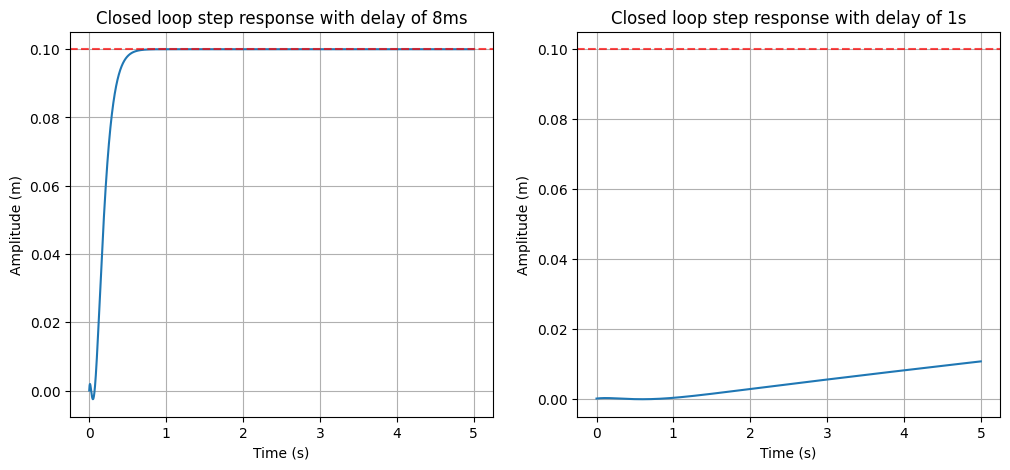

In [146]:
# Calculate and plot the closed loop step response with delay
step_T2 = step_response(T2, T)
step_T2_ = step_response(T2_, T)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(step_T2.time, 0.1*step_T2.outputs)
ax[0].set_title("Closed loop step response with delay of 8ms")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude (m)")
ax[0].axhline(y=0.1, color='r', linestyle='--', alpha=0.7)
ax[0].grid()

ax[1].plot(step_T2_.time, 0.1*step_T2_.outputs) 
ax[1].set_title("Closed loop step response with delay of 1s")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Amplitude (m)")
ax[1].axhline(y=0.1, color='r', linestyle='--', alpha=0.7)
ax[1].grid()

In [145]:
# Print your steady state error for both delays

print("Steady state error at 5s with delay of 8ms: ", 0.1 - 0.1*step_T2.outputs[-1]) # e(t) = r(t) - y(t)
if((0.1 - 0.1*step_T2.outputs[-1]) < 0.001):
    print("steady state error is small enough for 8ms delay system!")
print("Steady state error at 5s with delay of 1s: ", 0.1 - 0.1*step_T2_.outputs[-1])


Steady state error at 5s with delay of 8ms:  2.5951463200613034e-14
steady state error is small enough for 8ms delay system!
Steady state error at 5s with delay of 1s:  0.08936146532247978


### Prelab Q4

When analyzing the system further you notice that the PID controller’s output exceeds the speed limits of your motors. What could be one of the problems you face?


<font color=orange> One possible problem I could face is integral windup. As the actuators saturate and can't meet the signals demands, the integral term accumulates the error over a long period of time. This cuases the control signal to grow very large as it tries to lower the accumulated error and can lead to instability. This can be mitigated using anti-windup, which limits the integral accumulation when the actuators saturate, as shown in Figure 6.4 in the Lab handout. </font>